<a href="https://colab.research.google.com/github/AkemjotSingh/csot-ml-astronomy-akemjotsingh/blob/main/week3_eval_starter_akemjotsingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 3 . Part 2: Evaluation and Interpretation (Starter)

**Goal:** Evaluate the CNN honestly. Track train-vs-validation loss, report a **test accuracy** that beats the Week-2 baseline, build a **confusion matrix** you can read astrophysically, and **save** the trained weights.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`).
2. Read [`05-evaluation-and-overfitting.md`](../05-evaluation-and-overfitting.md), [`06-confusion-matrix-and-metrics.md`](../06-confusion-matrix-and-metrics.md), and [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).

Replace each `TODO`. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Data + model

Re-create the Week-1 `DataLoader`s and your `GalaxyCNN` (paste both from Part 1). You can either re-train here, or load Part 1's `galaxy_model.pth`. After this section you need: `train_loader`, `val_loader`, `test_loader`, `test_ds`, `num_classes`, `model`, `criterion`, `optimizer`.

In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# TODO: paste the Week-1 data pipeline AND your GalaxyCNN definition from Part 1, so that
#   train_loader, val_loader, test_loader, test_ds, num_classes, model, criterion, optimizer
# are all defined. Move model to device. (Optionally load Part-1 weights:
#   model.load_state_dict(torch.load('galaxy_model.pth', map_location=device)) )
from google.colab import files

files.upload()

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install kaggle -q
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw

!wget -q "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz" -O galaxy_raw/gz2_hart16.csv.gz
!gunzip galaxy_raw/gz2_hart16.csv.gz

RAW_ROOT   = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT  = Path("galaxy_data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:46<00:00, 70.6MB/s]



In [10]:
def high_level_label(gz2_class):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, ...) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    return df.dropna(subset=["label"]).reset_index(drop=True)


def _link_image(src, dst):
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(images_dir, df, out_root, per_class=200,
                                   train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    images_dir, out_root = Path(images_dir), Path(out_root)
    summary = {}
    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)
        n = len(rows)
        n_train = int(train_frac * n); n_val = int(val_frac * n)
        splits = {"train": rows.iloc[:n_train],
                  "val": rows.iloc[n_train:n_train + n_val],
                  "test": rows.iloc[n_train + n_val:]}
        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary
df = load_labeled_table(RAW_ROOT / "gz2_filename_mapping.csv", RAW_ROOT / "gz2_hart16.csv")
build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=200)
print("layout built")

layout built


In [11]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "| num_classes:", num_classes)

classes: ['elliptical', 'spiral', 'spiral_barred'] | num_classes: 3


In [12]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 16 * 16, 128), nn.ReLU(), nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = GalaxyCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 1 - The evaluation function

Write `evaluate(model, loader, criterion, device)` that returns `(avg_loss, accuracy)`. It MUST use `model.eval()` and `torch.no_grad()`. Predicted class = `outputs.argmax(dim=1)`.

In [13]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

## Step 2 - Train while tracking validation

Run the training loop again, but each epoch also call `evaluate(model, val_loader, ...)`. Record `train_losses` and `val_losses` (and optionally `val_accs`).

In [14]:
num_epochs = 8
train_losses, val_losses, val_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running += loss.item() * inputs.size(0)
    train_loss = running / len(train_loader.dataset)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss); val_losses.append(val_loss); val_accs.append(val_acc)
    print(f"Epoch {epoch+1:2d}  train {train_loss:.3f}  val {val_loss:.3f}  val_acc {val_acc:.3f}")

Epoch  1  train 1.151  val 1.098  val_acc 0.333
Epoch  2  train 1.097  val 1.093  val_acc 0.411
Epoch  3  train 1.084  val 1.075  val_acc 0.444
Epoch  4  train 1.045  val 1.052  val_acc 0.467
Epoch  5  train 1.017  val 1.050  val_acc 0.433
Epoch  6  train 0.978  val 1.068  val_acc 0.444
Epoch  7  train 0.963  val 1.062  val_acc 0.467
Epoch  8  train 0.942  val 1.076  val_acc 0.456


## Step 3 - Plot train vs validation loss

Plot both on one axis. A widening gap (train falling, val rising) is the overfitting signature.

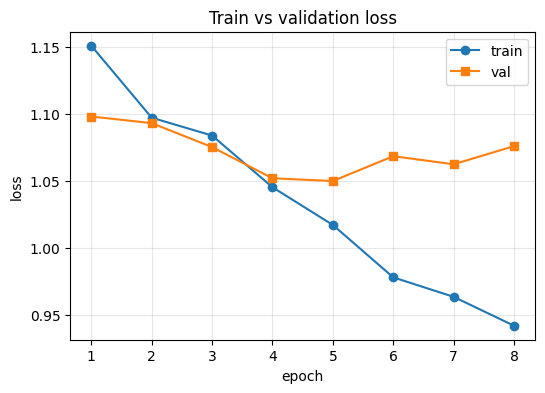

In [15]:
# TODO: plt.plot(train_losses, label='train'); plt.plot(val_losses, label='val')
#       label axes; legend; title; show. Then comment (Markdown) on overfitting.
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, num_epochs + 1), val_losses, marker="s", label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("Train vs validation loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 4 - Final test accuracy vs the Week-2 baseline

Evaluate ONCE on the test set. State your Week-2 baseline number and the improvement.

In [17]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"FINAL test accuracy: {test_acc:.3f}")

week2_baseline = 0.456  # <-- replace with YOUR Week-2 KNN/LogReg test accuracy
print(f"Week-2 baseline: {week2_baseline:.3f}")
print(f"Improvement over baseline: {test_acc - week2_baseline:+.3f}")

FINAL test accuracy: 0.378
Week-2 baseline: 0.456
Improvement over baseline: -0.078


## Step 5 - Confusion matrix

Collect predictions across the test set (move them to CPU before NumPy!), then display a labelled confusion matrix using `test_ds.classes`.

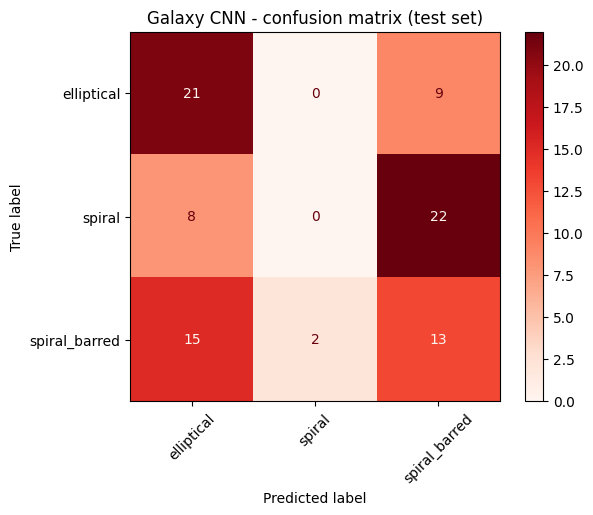

In [19]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, targets in loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(targets)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

y_pred, y_true = collect_predictions(model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Reds", xticks_rotation=45)
plt.title("Galaxy CNN - confusion matrix (test set)")
plt.show()

## Step 6 - Per-class report + astrophysical reading

Print `classification_report`, then in a Markdown cell name the most-confused pair and link it to the astronomy (density waves / bars in [`04`](../04-spiral-structure-and-star-formation.md); lenticulars / mergers in [`08`](../08-lenticulars-mergers-and-evolution.md)).

In [20]:
print(classification_report(y_true, y_pred, target_names=test_ds.classes))

               precision    recall  f1-score   support

   elliptical       0.48      0.70      0.57        30
       spiral       0.00      0.00      0.00        30
spiral_barred       0.30      0.43      0.35        30

     accuracy                           0.38        90
    macro avg       0.26      0.38      0.31        90
 weighted avg       0.26      0.38      0.31        90



## Step 7 - Save and reload (round-trip check)

Save the `state_dict`, load it into a fresh `GalaxyCNN`, and assert the reloaded test accuracy matches the original.

In [21]:
torch.save(model.state_dict(), "galaxy_model.pth")
print("saved galaxy_model.pth")

loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load("galaxy_model.pth", map_location=device))
loaded.eval()

_, reloaded_acc = evaluate(loaded, test_loader, criterion, device)
print(f"original test acc: {test_acc:.4f}")
print(f"reloaded test acc: {reloaded_acc:.4f}")
assert abs(reloaded_acc - test_acc) < 1e-6, "Reloaded model differs - check architecture/state_dict!"
print("Round-trip verified: weights saved and restored correctly.")

saved galaxy_model.pth
original test acc: 0.3778
reloaded test acc: 0.3778
Round-trip verified: weights saved and restored correctly.


## Reflection *(write 2-3 sentences each)*

1. What test accuracy did you reach, and by how much did the CNN beat the Week-2 baseline?
2. Did your curves show overfitting? How could you tell, and what would you try next?
3. Which two classes were confused most, and is that a model failure, a real physical ambiguity, or both?
4. Why is the save/reload round-trip check worth running rather than assuming it worked?

Answer 1: 0.378; 0.078

Answer 2: Yes, Training loss was continuously decreasing while Validation loss showed a minima; the fixes worth trying are data augmentation (flips/rotations - natural for galaxies), more data (raise PER_CLASS), early stopping, or dropout.

Answer 3: spiral and spiral-barred, no the limitation lies in the pixels used, which don't give the clarity over the bar centre which is the only thing which can differentiate between them.

Answer 4:Saving can silently go wrong (wrong path, saved before training finished, architecture mismatch). Asserting that the reloaded model reproduces the exact accuracy turns 'I think I saved it' into 'I know I can ship it'.